In [1]:
from dllib import Tensor, Linear, ReLU, Sequential, Conv2D, Flatten
import numpy as np

linear = Linear(2, 2)
linear.W = Tensor([[1,1],[1,1]])
# print(linear.__call__(Tensor([[1,2]])))

# 2 Kernels of size 2x2
conv = Conv2D(2, 2)
conv.kernels[0].W.data = np.array([1,1,1,1])
conv.kernels[1].W.data = np.array([1,1,1,1])
image = Tensor([[1,2,3,4],[5,6,7,8],[9,10,11,12],[13,14,15,16]])
w = Linear(18,1)
# conv.__call__(image)

a = conv(image)
b = a.flatten()
c = w(b)

c.backward()
print(c)
print(conv.kernels[0].W.grad)
print(conv.kernels[1].W.grad)

# model = Sequential(
#     Conv2D(2, 2),
#     Flatten(),
#     Linear(18, 4),
#     ReLU(),
#     Linear(4, 1),
# )

# model(image)

[[-20.24910258]]
[[0.]
 [0.]
 [0.]
 [0.]]
[[0.]
 [0.]
 [0.]
 [0.]]


In [13]:
from sklearn.datasets import load_digits
digits = load_digits()
print(digits.data.shape)
print(digits.target.shape)
print(digits.data[0])
print(digits.data.reshape(1797, 8, 8)[0])

(1797, 64)
(1797,)
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


np.int64(2)

In [1]:
from dllib import Tensor, Linear, ReLU, Sequential, Conv2D, Flatten, cross_entropy
import numpy as np
from sklearn.datasets import load_digits
digits = load_digits()

reshaped_data = digits.data.reshape(1797, 8, 8)

X = Tensor(reshaped_data)
Y = Tensor(digits.target) 


model = Sequential(
    Conv2D(3, 3),
    Flatten(),
    Linear(108, 10),
    ReLU(),
    Linear(10, 10),
    Flatten()
)

mse_log = []

for epoch in range(1, 10):
        mses = np.array([])
        for x, y in zip(X.data, Y.data):
            inp    = Tensor(x)
            target = Tensor([[y]])
            # print("inp", inp)
            pred   = model(inp)
            # print(pred)
            # print("got pred", pred)
            # mse   = ((pred - target) * (pred - target))
            ce = cross_entropy(pred, int(y))

            # Clear gradients from previous epoch.
            model_params = model.parameters()
            for p in model_params:
                p.grad = np.zeros_like(p.data)

            # Calculate new gradients.
            # mse.backward()
            ce.backward()
            # print(p.grad)

            # Update weights.
            for p in model_params:
                p.data -= 0.05 * p.grad

            mses = np.append(mses, ce.data)
            # mses = np.append(mses, mse.data)


        mse_mean = mses.mean()
        mse_log.append(mse_mean)
    
        if epoch % 1 == 0:
            print(f"epoch {epoch:4d} | loss {mse_mean:.4f}")


epoch    1 | loss 1.3625
epoch    2 | loss 0.3186
epoch    3 | loss 0.2237
epoch    4 | loss 0.1820
epoch    5 | loss 0.1617
epoch    6 | loss 0.1422
epoch    7 | loss 0.1255
epoch    8 | loss 0.1166
epoch    9 | loss 0.1071


In [5]:
np.set_printoptions(precision=3, suppress=True)
for i in range(10):
    logits = model(Tensor(reshaped_data[i])).data
    shifted = logits - np.max(logits)
    exps = np.exp(shifted)
    probs = exps / np.sum(exps)
    print(probs, " - ", digits.target[i])


[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]  -  0
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]  -  1
[0.    0.001 0.908 0.    0.    0.    0.001 0.    0.091 0.   ]  -  2
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]  -  3
[0.    0.    0.    0.    0.998 0.    0.002 0.    0.    0.   ]  -  4
[0.002 0.    0.    0.041 0.    0.001 0.    0.    0.081 0.876]  -  5
[0.    0.    0.    0.    0.    0.    0.999 0.    0.001 0.   ]  -  6
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]  -  7
[0.    0.    0.    0.    0.    0.    0.003 0.    0.996 0.   ]  -  8
[0.001 0.    0.    0.    0.    0.    0.    0.    0.    0.999]  -  9


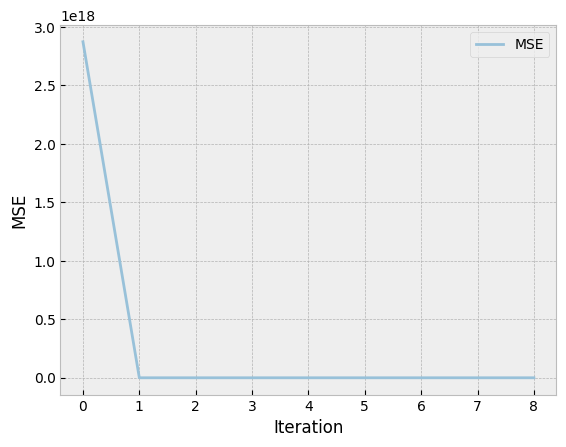

In [3]:
import matplotlib.pyplot as plt

plt.style.use('bmh') 
colors = ["#3d5a80","#98c1d9","#e0fbfc","#ee6c4d","#293241"]

plt.plot(mse_log, c=colors[1], label="MSE")
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.legend()
plt.savefig("plot.png")